In [8]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

sentences = [
    "I love deep learning",
    "I enjoy neural networks",
    "The sky is blue"
]

embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)


Embedding shape: (3, 384)


In [9]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

similarity_matrix

array([[ 1.0000002 ,  0.7668172 ,  0.007457  ],
       [ 0.7668172 ,  1.0000002 , -0.00119815],
       [ 0.007457  , -0.00119815,  0.99999994]], dtype=float32)

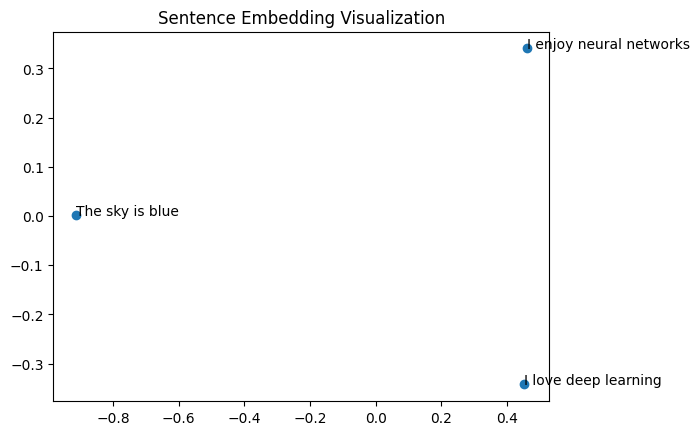

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.scatter(reduced[:,0], reduced[:,1])

for i, txt in enumerate(sentences):
    plt.annotate(txt, (reduced[i,0], reduced[i,1]))

plt.title("Sentence Embedding Visualization")
plt.show()

In [3]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

documents = [
    "Transformers use self-attention to model relationships between tokens.",
    "CNNs are mainly used for image processing tasks.",
    "RAG combines retrieval with text generation.",
    "FAISS is a library for efficient similarity search."
]

doc_embeddings = model.encode(documents)


In [4]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

query = "How does attention work in transformers?"
query_embedding = model.encode([query])

scores = cosine_similarity(query_embedding, doc_embeddings)[0]

top_k = 2
top_indices = np.argsort(scores)[::-1][:top_k]

for idx in top_indices:
    print(f"Score: {scores[idx]:.3f}")
    print(f"Document: {documents[idx]}\n")


Score: 0.602
Document: Transformers use self-attention to model relationships between tokens.

Score: 0.289
Document: CNNs are mainly used for image processing tasks.



In [5]:
import faiss
import numpy as np

dimension = doc_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(doc_embeddings)

print("Total vectors indexed:", index.ntotal)


Total vectors indexed: 4


In [6]:
query_embedding = model.encode([query]).astype("float32")

k = 2
distances, indices = index.search(query_embedding, k)

for i in indices[0]:
    print(documents[i])

Transformers use self-attention to model relationships between tokens.
CNNs are mainly used for image processing tasks.


In [7]:
def retrieve_context(query, k=3):
    q_emb = model.encode([query]).astype("float32")
    _, idx = index.search(q_emb, k)
    return [documents[i] for i in idx[0]]

retrieve_context("Explain retrieval augmented generation")


['RAG combines retrieval with text generation.',
 'Transformers use self-attention to model relationships between tokens.',
 'FAISS is a library for efficient similarity search.']